# Thermodynamic diagrams
We create thermo diagrams as described in p.63, ch.3, 4 and 5 of the book by R. Stull *Practical Meteorology*

In [59]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

A thermo diagram contains, in addition to the pressure and temperature grid lines, also dry and wet adiabats that can help at intepreting the state of the atmosphere from the temperature profile. The dry adiabats can be drawn from the equation of the potential temperature as a function of pressure used as a proxy for the elevation
$$T_2 = T_1 \cdot \left ( \frac{p_2}{p_1}\right ) ^{\frac{R_d}{c_p}} $$

In [60]:
def p_theta(T, theta):
    '''
    This function computes the dry adiabat for the potential temperature
    (theta) given as argument.
    '''
    T_0 = 273.15
    K = T + T_0
    theta_k = theta + T_0
    R_d = 287.08 # J/(KgK) gas constant for dry air
    c_p = 1004 # J(KgK) specific heat for dry air at constant pressure
    p_0 = 100 # kPa 
    p = p_0 / (theta_k / K) ** (c_p / R_d)
    return p

## Dry adiabats
We collect a number of dry adiabats

In [61]:
t_diagrams = [] 
T = np.linspace(-60, 70)
for theta in range(-60,70, 10):
    p = p_theta(T, theta)
    t_diagrams.append(p)

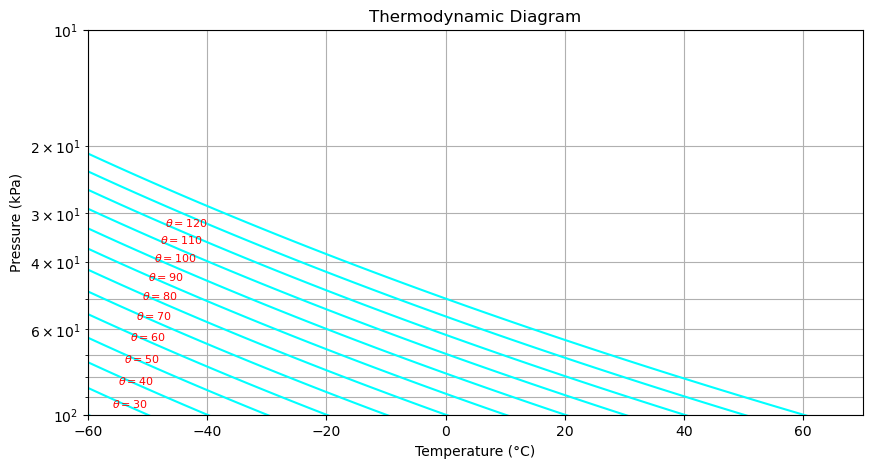

In [62]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.yaxis.set_inverted(True)
ax.set_ylim(100, 10)
ax.set_xlim(-60, 70)
ax.set_title("Thermodynamic Diagram")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
for i in range(0, len(t_diagrams)):
    ax.semilogy(T, t_diagrams[i], color='cyan', label='$\\theta = ' + str(i) + ' °C$')
    #ax.text(T[i], t_diagrams[i][10] + 50, r'$\theta$')
    x = T[0] + i
    y = t_diagrams[i][10]
    ax.annotate('$\\theta = ' + str(i * 10) + '$', xy=(x, y), xytext=(x + 1.0, y + 0.8), rotation=0, size=8, color='red')
#ax.legend();

## Skew-T Log-P
The Skew T - Log P diagram is a thermodynamic diagram for the profile of atmospheric temperature as a function of pressure representing elevation. The temperature profile provides the state of the atmosphere: the inversion layers, the levels of water vapor condensation and, together with the wind profile at altitude and a terrain model, estimates of possible precipitation and its amount can be made. The graph is semilogarithmic and together with the pressure and temperature coordinates also reports the curves of the dry (yellow line) and wet adiabatics (purple line). In the figure is the graph of the temperature profile collected at 12:00 today 24 June 2026 by the Military Aeronautics in Pratica di Mare, one of the six Italian stations for the collection of atmospheric profiles. A temperature reversal is noted at 950 hPa (500 m.), then the profile follows dry adiabatics, without vapor condensation, and then from 500 hPa (5500 m.), after further reversals, follows a wet adiabaticity, indicating that condensation has occurred. From 200 hPa (12 km) the profile makes a sharp inversion, typical of the stratosphere. Knowing how to read these diagrams is of great importance for weather forecasting, especially in the short term.

In [63]:
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

# 1. Generate or import sample sounding data
# Pressure must go from high (surface) to low (top of atmosphere)
p = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]) * units.hPa
T = np.array([25, 20, 15, 5, -12, -23, -41, -52, -55, -56, -54]) * units.degC
Td = np.array([18, 14, 8, -2, -22, -35, -55, -65, -73, -80, -85]) * units.degC

# Wind components for the barbs
wind_speed = np.array([10, 15, 20, 30, 45, 55, 70, 85, 90, 80, 60]) * units.knots
wind_dir = np.array([180, 190, 210, 230, 250, 260, 270, 270, 280, 280, 290]) * units.degrees
u, v = mpcalc.wind_components(wind_speed, wind_dir)

In [64]:
def plot_thermodiagram(p, variable, save_diagram=False):
    # 2. Set up the figure and SkewT object
    fig = plt.figure(figsize=(9, 9))
    # 'rotation=45' controls the slant of the temperature lines
    skew = SkewT(fig, rotation=45)

    # 3. Plot the environmental profiles
    # Note: MetPy requires (pressure, variable) order for plotting
    skew.plot(p, variable, 'r', linewidth=2, label='Temperature')
    #skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')

    # 4. Plot wind barbs on the right axis
    #skew.plot_barbs(p, u, v)

    # 5. Add standard thermodynamic background lines
    skew.plot_dry_adiabats(colors='orange', alpha=0.4, linewidths=1)
    skew.plot_moist_adiabats(colors='blue', alpha=0.4, linewidths=1)
    skew.plot_mixing_lines(colors='green', alpha=0.3, linewidths=1, linestyle=':')

    # 6. Customize axes limits and labels
    skew.ax.set_xlim(-40, 40)
    skew.ax.set_ylim(1050, 100) # Flipped so high pressure is at the bottom

    plt.title('Skew-T ln P Diagram', fontsize=14, fontweight='bold')
    skew.ax.set_xlabel('Temperature (°C)')
    skew.ax.set_ylabel('Pressure (hPa)')
    skew.ax.legend();
    if (save_diagram == True):
        plt.savefig('data/skewTlnp_diagram.jpg')

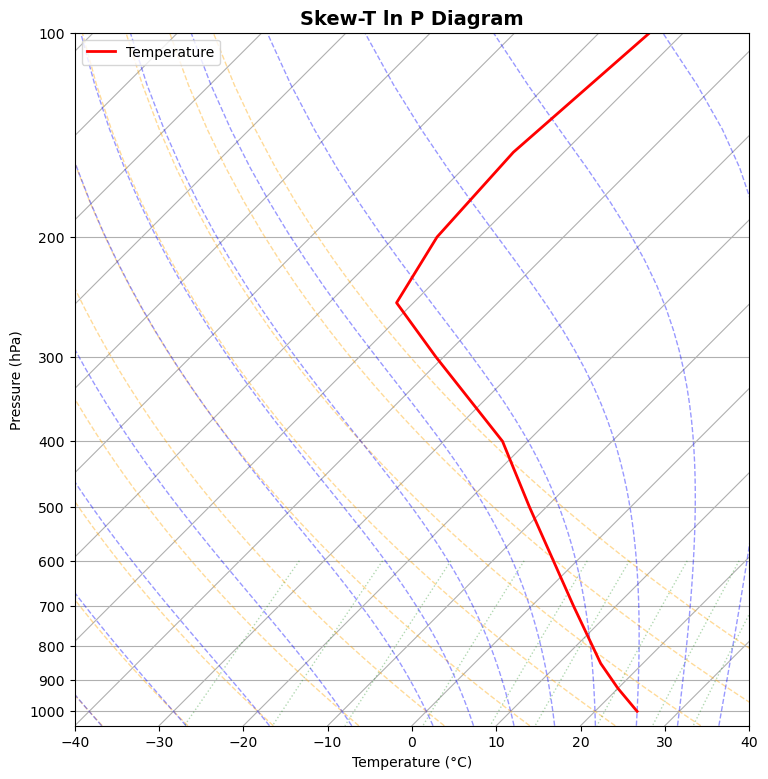

In [65]:
plot_thermodiagram(p, T)

In [66]:
radiosonde_path = 'data/pratica_di_mare/2026062412-16245.csv'
radiosonde_df = pd.read_csv(radiosonde_path, index_col=0)
radiosonde_df.head()

,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
pressure_hPa,,,,,,,,,
1012.0,32,31.8,20.8,20.8,52,52,15.45,250,2.1
1009.0,59,29.4,19.4,19.4,55,55,14.18,246,2.3
1002.0,122,29.0,19.0,19.0,55,55,13.92,238,2.9
1000.0,140,29.2,19.2,19.2,55,55,14.13,235,3.1
976.0,356,26.6,18.6,18.6,62,62,13.94,193,3.1


In [67]:
rs_pressure = radiosonde_df.index.to_numpy() * units.hPa

In [68]:
rs_temperature = radiosonde_df['temperature_C'].to_numpy() * units.degC

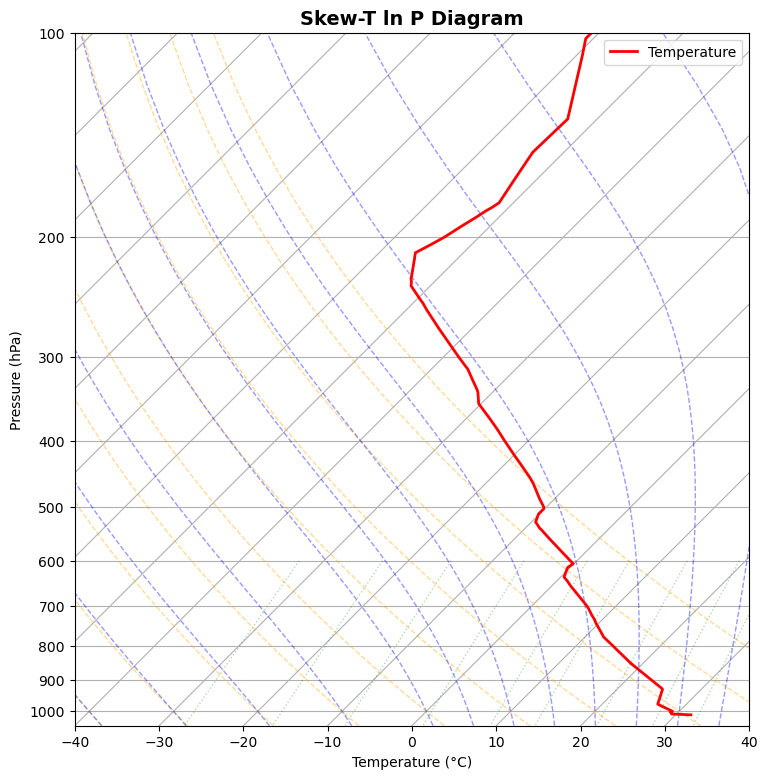

In [69]:
plot_thermodiagram(rs_pressure, rs_temperature)

In [70]:
radiosonde_path_1 = 'data/pratica_di_mare/2026062312-16245.csv'
radiosonde_df_1 = pd.read_csv(radiosonde_path, index_col=0)

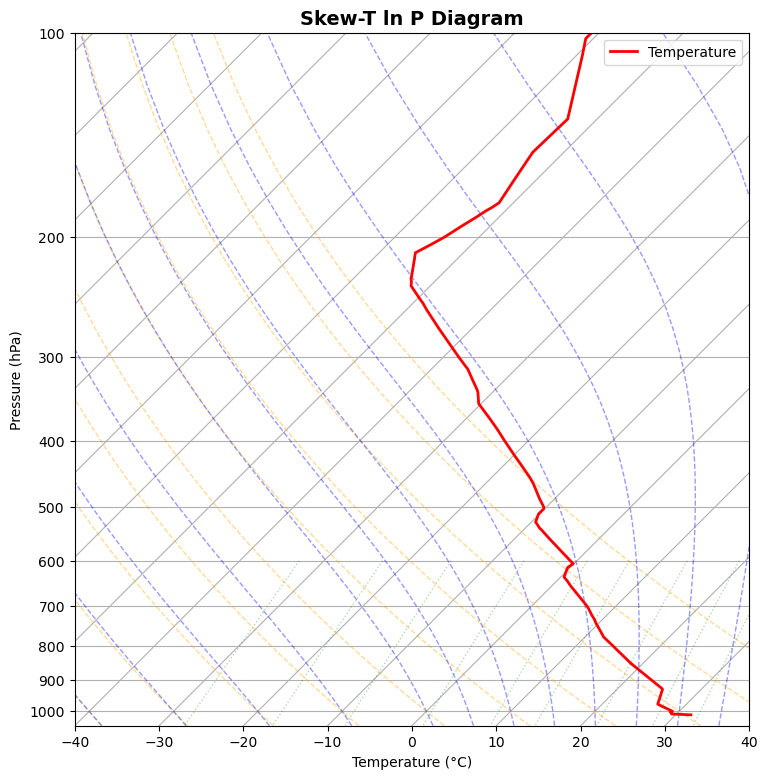

In [71]:
rs_pressure_1 = radiosonde_df_1.index.to_numpy() * units.hPa
rs_temperature_1 = radiosonde_df_1['temperature_C'].to_numpy() * units.degC
plot_thermodiagram(rs_pressure_1, rs_temperature_1, True)

## References and datasets
* [University of Wyoming Atmospheric Science Radiosonde Archive](https://weather.uwyo.edu/upperair/sounding.shtml)
* [Aeronautica Militare Italiana - Il Servizio di Radiosondaggio automatico dell'atmosfera](https://www.meteoam.it/it/autosonda)
* [VAISALA - Radiosonde RS41-SG](https://docs.vaisala.com/v/u/B211321EN-L/en-US)
* [Copernicus In-Situ](https://insitu.copernicus.eu/)
* [Copernicus In-Situ Data Providers](https://insitu.copernicus.eu/state-of-play/data-providers)
* [WMO - Global Observing System](https://wmo.int/activities/global-observing-system-gos/global-observing-system-gos)
* [WMO Oscar Surface](https://oscar.wmo.int/surface/#/)